In [12]:
import os
import pickle
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams, cycler
from matplotlib.cm import ScalarMappable
import seaborn as sns
import tensorflow as tf
from scipy.stats import pearsonr, gaussian_kde, ecdf
from sklearn.decomposition import PCA
import sys
sys.path.append(os.path.join('c:\\', *os.getcwd().split('\\')[1:-1]))
from sgcc import *

In [13]:
plt.rcParams['figure.dpi'] = 300
fontsize = 8
linewidth = 0.5

In [14]:
files = [
    'sgcc_mop_3_11_26.pkl',
    'conditional_optimization_relaxedbounds_plus_perturbation.pkl',
    'conditional_optimization_clipped_fts.pkl',
    'conditional_optimization_clipped_duration.pkl',
    'conditional_optimization_clipped_fti.pkl',
    'conditional_optimization_clipped_fts_and_fti.pkl',
    'conditional_optimization_clipped_fts_and_duration.pkl',
    'conditional_optimization_clipped_fti_and_duration.pkl',
    'conditional_optimization_clipped_fts_fti_duration.pkl'
]

data = {}
labels = [
    'original',
    'relaxed_bounds',
    'frozen_fts',
    'frozen_duration',
    'frozen_fti',
    'frozen_fts_fti',
    'frozen_fts_duration',
    'frozen_fti_duration',
    'frozen_fts_fti_duration',
]

for label, file in zip(labels, files):
    modfile = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', file)
    with open(modfile, 'rb') as f:
        optimized_model = pickle.load(f)
    data[label] = optimized_model
    del optimized_model

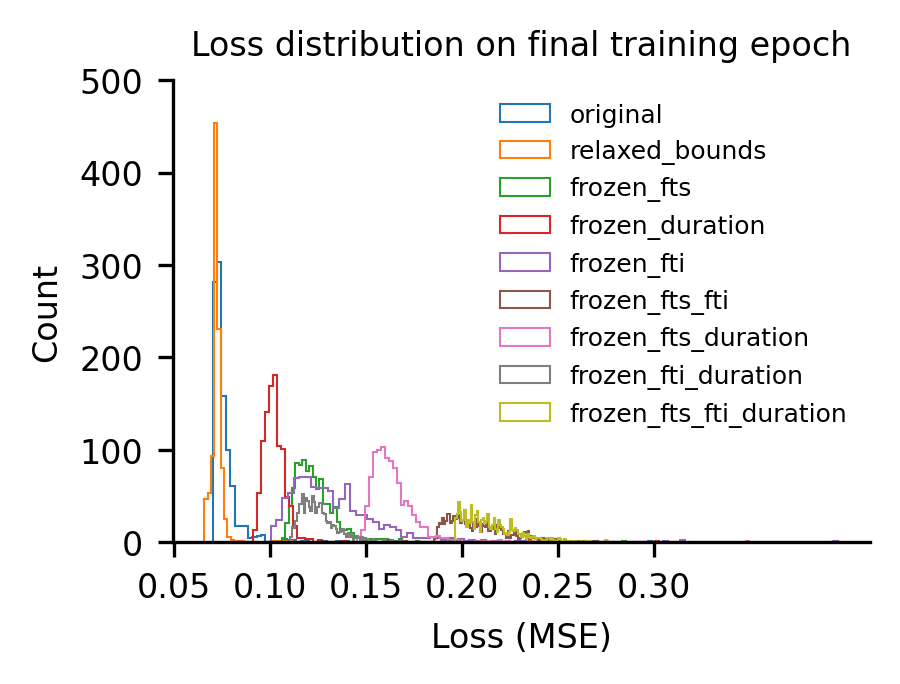

In [ ]:
fig, ax = plt.subplots(figsize = (3,2))

ax.tick_params(labelsize = fontsize)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel("Count", fontsize = fontsize)
ax.set_xlabel("Loss (MSE)", fontsize = fontsize)
ax.set_xticks(np.arange(0,0.35,0.05))
ax.set_ylim(0,500)
ax.set_title("Loss distribution on final training epoch", fontsize = fontsize)
for key, val in data.items():
    ax.hist(val['loss_decay'][-1], bins = 100, label = key, histtype='step', linewidth = 0.5)

ax.legend(fontsize = 6, frameon = False)

C:\Users\Sturdy\AppData\Local\Temp\ipykernel_48120\3837096008.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(list(data.keys()), fontsize = fontsize, rotation = 50, ha = 'right')


<ErrorbarContainer object of 3 artists>

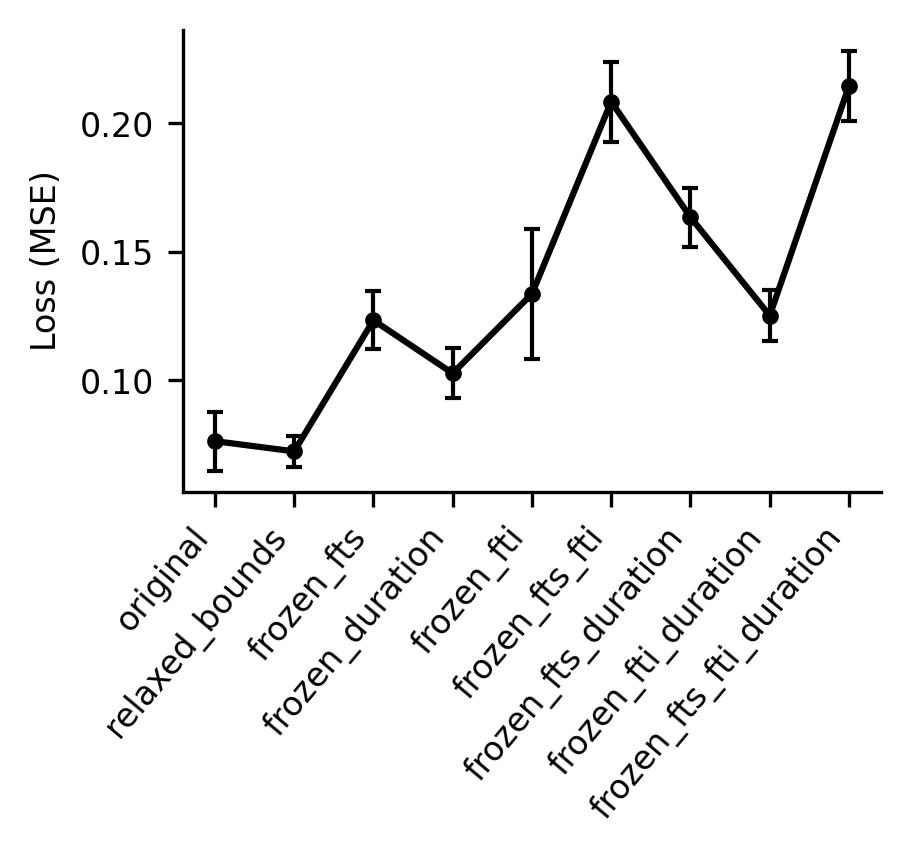

In [18]:
fig, ax = plt.subplots(figsize = (3,2))

ax.tick_params(labelsize = fontsize)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel("Loss (MSE)", fontsize = fontsize)
ax.set_xticklabels(list(data.keys()), fontsize = fontsize, rotation = 50, ha = 'right')
means = [
    val['loss_decay'][-1].mean()
    for key, val in data.items()
]
errors = [
    val['loss_decay'][-1].std()
    for key, val in data.items() 
]
ax.errorbar(
    list(data.keys()),
    means,
    np.array(errors),
    color = 'black',
    fmt="-o",
    markersize = 3,
    elinewidth=1,
    capsize=2
)

In [6]:
loss_lower_bound = np.min(data['original']['loss_decay'][-1])
loss_upper_bound = np.median(data['original']['loss_decay'][0])

In [7]:
def variance_explained(
        loss,
        loss_lower_bound,
        loss_upper_bound,
):
    total = np.log2(loss_upper_bound) - np.log2(loss_lower_bound)
    val = np.log2(loss) - np.log2(loss_lower_bound)
    return 1-(val/total)

In [8]:
ve = []
for key in data.keys():
    ve.append(variance_explained(
        np.median(data[key]['loss_decay'][-1]),
        loss_lower_bound,
        loss_upper_bound,
    ))

C:\Users\Sturdy\AppData\Local\Temp\ipykernel_48120\3310103399.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(list(data.keys()), fontsize = fontsize, rotation = 50, ha = 'right')


<BarContainer object of 9 artists>

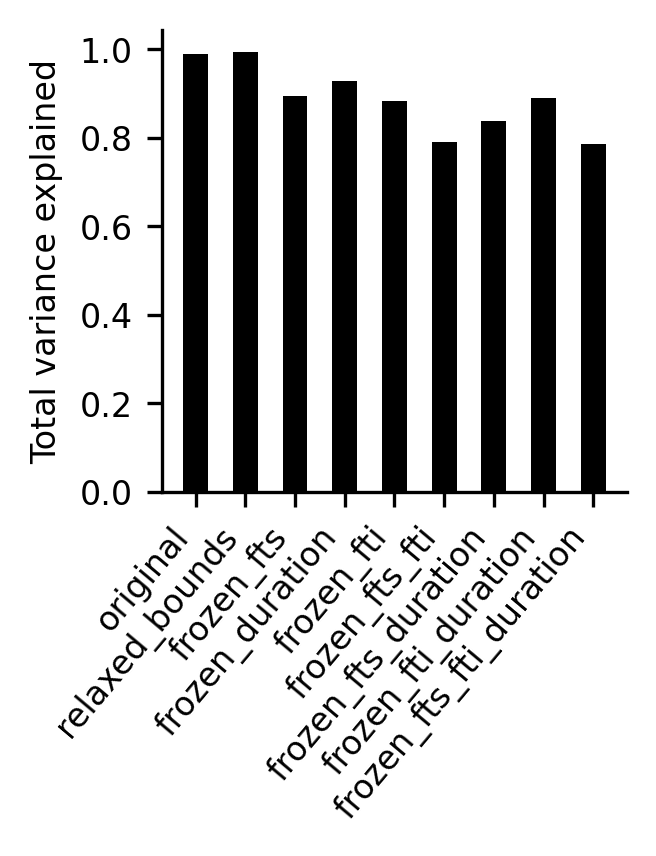

In [9]:
fig, ax = plt.subplots(figsize = (2,2))

ax.tick_params(labelsize = fontsize)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel("Total variance explained", fontsize = fontsize)
ax.set_xticklabels(list(data.keys()), fontsize = fontsize, rotation = 50, ha = 'right')
ax.bar(
    list(data.keys()),
    ve,
    color = 'black',
    width=0.5
)